# 04. Train, Validation, Test Splits, and Leakage Control

A machine-learning workflow is only as honest as its evaluation design. Teams often talk about train, validation, and test sets as if they were bookkeeping objects that appear after the real modeling work. In practice, the opposite is closer to the truth: the split strategy determines which deployment question is being answered, which kinds of mistakes can be detected, and how much optimism can quietly enter the reported metrics.

This lecture studies evaluation design directly. We will work through a synthetic support-operations panel in which the same predictive model can look reliable, fragile, or suspiciously excellent depending on how we split the data and which features we allow into the workflow. That perspective aligns with several recurring arguments in the literature: predictive modeling should be judged in relation to the problem it is being asked to solve (Breiman, 2001), leakage can make a model appear far stronger than it really is (Kaufman et al., 2012), structured data require validation strategies that respect the dependence structure (Roberts et al., 2017; Wieczorek et al., 2022), and performance estimates can become optimistic when model selection bleeds into evaluation (Ambroise & McLachlan, 2002).

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain the distinct roles of training, validation, and test sets in predictive modeling.
2. Match a split strategy to a concrete deployment question rather than defaulting to a random holdout.
3. Diagnose why grouped and temporal data require different validation designs from IID row-level data.
4. Show how reusing the test set for tuning quietly converts it into a validation set.
5. Detect leakage from post-outcome features and from evaluation designs that ignore timing or entity structure.
6. Use rolling validation to reveal drift that a single holdout can hide.


## 1. Evaluation Begins With the Deployment Question

Before fitting any model, ask what kind of future the evaluation should mimic.

| Split family | What future it approximates | Good use case | Common failure mode |
|---|---|---|---|
| Random row split | More rows drawn from roughly the same mixture as the observed sample | Tabular data with weak dependence and no important time order | Accidentally mixing repeated entities, near-duplicates, or future rows into both train and test |
| Group split | New entities from the same operating regime | Customers, devices, patients, merchants, or tickets with repeated rows | Treating grouped data as IID and reporting inflated performance |
| Temporal split | Future data after the present decision date | Forecasting, monitoring, churn, demand, reliability, and other operational time problems | Letting future conditions leak into model fitting or validation |
| Rolling validation | A sequence of future periods | Model monitoring, threshold maintenance, and drift detection | Hiding regime changes behind one lucky holdout |

The three-way separation also has distinct jobs:

| Data partition | Main role | What should happen there |
|---|---|---|
| Train | Fit model parameters | Learn coefficients, trees, embeddings, and other model internals |
| Validation | Choose among alternatives | Tune hyperparameters, compare candidate workflows, and choose thresholds |
| Test | Final external report | Evaluate the chosen workflow once, after tuning decisions are finished |

A practical implication follows immediately: if the test set is consulted repeatedly while choosing models, features, or thresholds, it is no longer a true test set. It has become another validation surface.


### Mathematical Spine: Evaluation Targets, Hyperparameter Selection, and Leakage

Train, validation, and test splits exist because the analyst is trying to estimate **future deployment risk** alongside training fit. If a learning algorithm trained on \(D_{\text{train}}\) with tuning choice \(\lambda\) produces predictor \(\hat f_{\lambda}\), then the validation estimator is

$$
\hat R_{\text{val}}(\lambda)
= \frac{1}{n_{\text{val}}}
\sum_{i \in D_{\text{val}}}
L\big(y_i, \hat f_{\lambda}(x_i)\big).
$$

We choose the tuning parameter by minimizing validation error:

$$
\hat \lambda = \arg\min_{\lambda \in \Lambda} \hat R_{\text{val}}(\lambda).
$$

Only after that choice is fixed should we use the held-out test set to estimate final generalization performance:

$$
\hat R_{\text{test}}
= \frac{1}{n_{\text{test}}}
\sum_{i \in D_{\text{test}}}
L\big(y_i, \hat f_{\hat \lambda}(x_i)\big).
$$

This logic is especially important when the deployment target is temporal. If the real operational question is how well the model performs on future periods, then the target risk is closer to

$$
R_{\text{future}}(f) = \mathbb{E}_{(X_t, Y_t) \sim P_{t > T}}\big[L(Y_t, f(X_t))\big],
$$

not an arbitrary random split over mixed time periods.

Leakage occurs whenever the model is trained or evaluated on information unavailable at decision time. A simple formal warning sign is

$$
X_t^{\text{used}} = (X_t, Z_{t+\Delta}), \qquad \Delta > 0,
$$

meaning that some component of the feature vector is generated only after the forecast or intervention would have been made. That turns evaluation into a contaminated estimate of performance.

Repeatedly inspecting the test set creates a different problem. Every time we choose among models using test results, the test set stops behaving like an external holdout and begins to act like another validation set. In effect, the analyst is optimizing

$$
\min_{m \in \mathcal{M}} \hat R_{\text{test}}(m),
$$

which produces an optimistically biased estimate of out-of-sample performance. The practical rule is simple. validation is for choice, test is for audit.

In [1]:
# Section focus: Mathematical Spine: Evaluation Targets, Hyperparameter Selection, and Leakage.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "notebooks" / "_shared").exists())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", None)

late_regime_patch = Patch(
    facecolor="#D55E00",
    alpha=0.10,
    edgecolor="none",
    label="Late release-shock period (months 9-12)",
)


In [2]:
# Section focus: Mathematical Spine: Evaluation Targets, Hyperparameter Selection, and Leakage.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))


def make_one_hot_encoder():
    """Construct the one hot encoder helper used in the 04. Train, Validation, Test Splits, and Leakage Control workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Intermediate result produced by the one hot encoder calculation and reused by later cells.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(numeric_features, categorical_features):
    """Build the preprocessor object used in the 04. Train, Validation, Test Splits, and Leakage Control analysis.
    
    Parameters
    ----------
    numeric_features : object
        Numeric columns transformed or modeled in this workflow.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the preprocessor workflow.
    """
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", make_one_hot_encoder()),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def simulate_support_panel(n_accounts=700, n_months=12, random_state=2026):
    """Create a simulated support panel data set for the 04. Train, Validation, Test Splits, and Leakage Control case study.
    
    Parameters
    ----------
    n_accounts : object
        Number of account records to create for the simulated business setting.
    n_months : object
        Count or size setting for the support panel calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)
    months = np.arange(1, n_months + 1)

    regions = np.array(["North America", "Europe", "APAC", "LATAM"])
    tiers = np.array(["Basic", "Growth", "Premium", "Strategic"])
    industries = np.array(["SaaS", "FinTech", "Healthcare", "Manufacturing"])

    rows = []
    for account_number in range(1, n_accounts + 1):
        region = rng.choice(regions, p=[0.38, 0.25, 0.22, 0.15])
        tier = rng.choice(tiers, p=[0.24, 0.36, 0.28, 0.12])
        industry = rng.choice(industries)

        complexity = rng.normal(0, 1)
        sponsor_strength = rng.normal(0, 1)
        base_usage = rng.beta(4, 2)
        active_seats = np.exp(
            rng.normal(
                3.9 + 0.25 * (tier == "Premium") + 0.55 * (tier == "Strategic"),
                0.35,
            )
        )

        for month_index in months:
            release_shock = 1 if month_index >= 9 else 0
            seasonal = np.sin(2 * np.pi * month_index / 12)

            usage_ratio = np.clip(
                base_usage
                + 0.08 * sponsor_strength
                - 0.06 * complexity
                - 0.10 * release_shock
                + rng.normal(0, 0.08),
                0.02,
                0.99,
            )
            backlog_ratio = np.clip(
                0.45
                + 0.18 * complexity
                - 0.12 * sponsor_strength
                + 0.10 * release_shock
                + rng.normal(0, 0.12),
                0.01,
                0.99,
            )
            critical_incidents_30d = int(
                max(
                    0,
                    rng.poisson(
                        np.exp(-1.3 + 1.2 * complexity + 1.0 * backlog_ratio + 0.35 * release_shock)
                    ),
                )
            )
            avg_response_hours_30d = np.exp(
                1.0
                + 0.22 * complexity
                - 0.16 * sponsor_strength
                + 0.55 * backlog_ratio
                + 0.15 * release_shock
                + rng.normal(0, 0.18)
            )
            prior_escalation_rate = np.clip(
                0.10
                + 0.10 * complexity
                - 0.08 * sponsor_strength
                + 0.04 * (month_index > 4)
                + rng.normal(0, 0.05),
                0,
                1,
            )

            latent_risk = (
                -2.6
                + 1.35 * complexity
                - 0.85 * sponsor_strength
                + 0.90 * backlog_ratio
                + 0.22 * critical_incidents_30d
                + 0.16 * np.log1p(avg_response_hours_30d)
                + 0.75 * release_shock
                + 0.18 * (region == "LATAM")
                + 0.12 * (tier == "Basic")
                + 0.18 * seasonal
            )
            breach_next_month = rng.binomial(1, sigmoid(latent_risk))

            # These are intentionally post-outcome operational reactions.
            war_room_hours_next_14d = max(
                0,
                rng.normal(2.0 + 8.5 * breach_next_month + 2.0 * backlog_ratio, 1.5),
            )
            rescue_override_next_14d = rng.binomial(
                1,
                min(0.05 + 0.70 * breach_next_month + 0.10 * release_shock, 0.95),
            )

            rows.append(
                {
                    "account_id": f"A{account_number:04d}",
                    "month_index": int(month_index),
                    "region": region,
                    "tier": tier,
                    "industry": industry,
                    "active_seats": float(active_seats),
                    "usage_ratio": float(usage_ratio),
                    "backlog_ratio": float(backlog_ratio),
                    "critical_incidents_30d": critical_incidents_30d,
                    "avg_response_hours_30d": float(avg_response_hours_30d),
                    "prior_escalation_rate": float(prior_escalation_rate),
                    "release_shock": release_shock,
                    "breach_next_month": breach_next_month,
                    "war_room_hours_next_14d": float(war_room_hours_next_14d),
                    "rescue_override_next_14d": rescue_override_next_14d,
                }
            )

    return pd.DataFrame(rows)


def evaluate_holdout(pipeline, train_frame, test_frame, features, target="breach_next_month"):
    """Evaluate holdout for the 04. Train, Validation, Test Splits, and Leakage Control decision workflow.
    
    Parameters
    ----------
    pipeline : object
        Scikit-learn pipeline that combines preprocessing and estimation.
    train_frame : object
        Training split or training value used by this workflow.
    test_frame : object
        Test split or held-out value used by this workflow.
    features : object
        Feature column names or feature matrix used by the model.
    target : object
        Target column name or target values used by the supervised task.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    pipeline.fit(train_frame[features], train_frame[target])
    score = pipeline.predict_proba(test_frame[features])[:, 1]
    metrics = {
        "roc_auc": roc_auc_score(test_frame[target], score),
        "pr_auc": average_precision_score(test_frame[target], score),
        "brier_score": brier_score_loss(test_frame[target], score),
        "observed_breach_rate": test_frame[target].mean(),
        "mean_predicted_risk": score.mean(),
    }
    return metrics, score


## 2. Synthetic Support-Operations Panel

We will study a monthly account panel for a software platform. The business question is whether an account is likely to experience a serious service breach next month. That prediction could drive staffing escalation, customer outreach, or proactive technical review.

The simulation includes three features that matter for evaluation design:

1. **Repeated entities**: each account appears month after month, so row-level observations are not independent.
2. **A later regime change**: months 9 through 12 include a product-release shock that increases breach risk.
3. **Tempting post-outcome fields**: the dataset logs reactive interventions after the risk has already become visible.

This means the notebook can distinguish among three different problems:

- how to split repeated account data,
- how to keep a true test set external to tuning,
- and how to stop future information from leaking backward into model training.


,quantity,value
0,Rows,8400.000000
1,Unique accounts,700.000000
2,Months,12.000000
3,Overall breach rate,0.295000
4,Late-period breach rate (months 9-12),0.372000


,account_id,month_index,region,tier,industry,active_seats,usage_ratio,backlog_ratio,critical_incidents_30d,avg_response_hours_30d,prior_escalation_rate,release_shock,breach_next_month,war_room_hours_next_14d,rescue_override_next_14d
0,A0001,1,North America,Premium,FinTech,58.612,0.625,0.686,5,4.754,0.120,0,1,12.858,1
1,A0001,2,North America,Premium,FinTech,58.612,0.555,0.702,2,3.933,0.197,0,1,13.931,1
2,A0001,3,North America,Premium,FinTech,58.612,0.658,0.518,3,5.196,0.199,0,0,1.798,0
3,A0001,4,North America,Premium,FinTech,58.612,0.615,0.711,4,6.602,0.230,0,1,13.414,1
4,A0001,5,North America,Premium,FinTech,58.612,0.566,0.590,3,4.176,0.179,0,1,10.227,1
5,A0001,6,North America,Premium,FinTech,58.612,0.494,0.780,5,7.688,0.199,0,1,12.742,1
6,A0001,7,North America,Premium,FinTech,58.612,0.515,0.779,0,6.742,0.193,0,1,11.112,0
7,A0001,8,North America,Premium,FinTech,58.612,0.605,0.669,6,3.484,0.164,0,1,14.889,1


,month_index,breach_rate,mean_usage_ratio,mean_backlog_ratio
0,1,0.270,0.658,0.452
1,2,0.271,0.661,0.449
2,3,0.264,0.658,0.452
3,4,0.273,0.656,0.447
4,5,0.273,0.661,0.448
5,6,0.253,0.657,0.454
6,7,0.221,0.661,0.444
7,8,0.220,0.658,0.452
8,9,0.364,0.563,0.547
9,10,0.363,0.557,0.538


,tier,rows,breach_rate,avg_response_hours
0,Basic,1884,0.262,3.946
1,Growth,3000,0.298,4.096
2,Premium,2580,0.299,4.111
3,Strategic,936,0.339,4.379


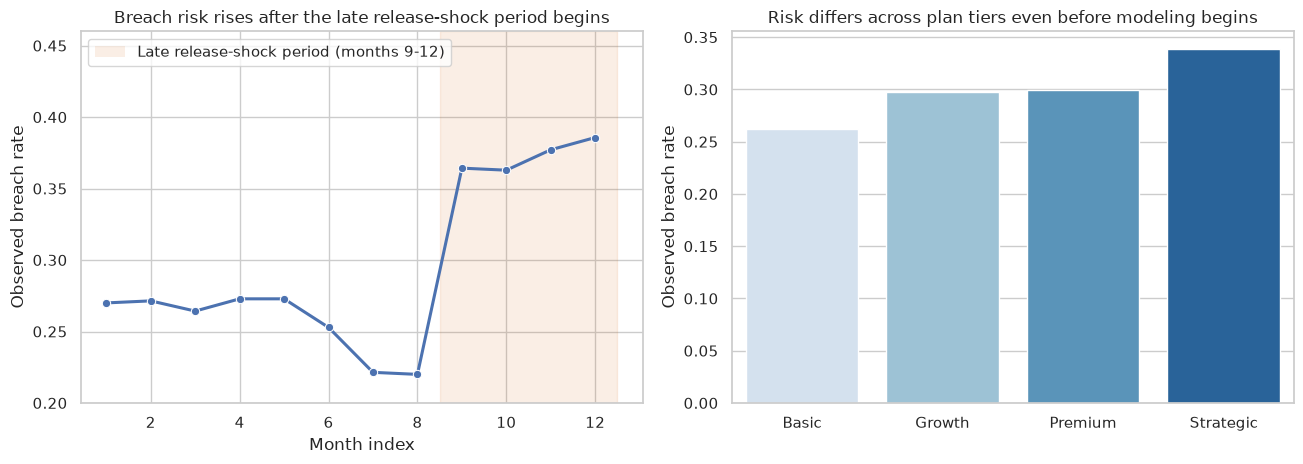

In [3]:
# Section focus: 2. Synthetic Support-Operations Panel.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

df = simulate_support_panel()

panel_overview = pd.DataFrame(
    [
        {"quantity": "Rows", "value": len(df)},
        {"quantity": "Unique accounts", "value": df["account_id"].nunique()},
        {"quantity": "Months", "value": df["month_index"].nunique()},
        {"quantity": "Overall breach rate", "value": round(df["breach_next_month"].mean(), 3)},
        {
            "quantity": "Late-period breach rate (months 9-12)",
            "value": round(df.loc[df["month_index"] >= 9, "breach_next_month"].mean(), 3),
        },
    ]
)

smart_display(panel_overview)
smart_display(df.head(8))

monthly_summary = (
    df.groupby("month_index", as_index=False)
    .agg(
        breach_rate=("breach_next_month", "mean"),
        mean_usage_ratio=("usage_ratio", "mean"),
        mean_backlog_ratio=("backlog_ratio", "mean"),
    )
)

tier_summary = (
    df.groupby("tier", as_index=False)
    .agg(
        rows=("account_id", "size"),
        breach_rate=("breach_next_month", "mean"),
        avg_response_hours=("avg_response_hours_30d", "mean"),
    )
)

smart_display(monthly_summary.round(3))
smart_display(tier_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

sns.lineplot(data=monthly_summary, x="month_index", y="breach_rate", marker="o", linewidth=2.2, ax=axes[0])
axes[0].axvspan(8.5, 12.5, color="#D55E00", alpha=0.10)
axes[0].set_title("Breach risk rises after the late release-shock period begins")
axes[0].set_xlabel("Month index")
axes[0].set_ylabel("Observed breach rate")
axes[0].set_ylim(0.20, 0.46)
axes[0].legend(handles=[late_regime_patch], loc="upper left", frameon=True)

sns.barplot(data=tier_summary, x="tier", y="breach_rate", palette="Blues", ax=axes[1])
axes[1].set_title("Risk differs across plan tiers even before modeling begins")
axes[1].set_xlabel("")
axes[1].set_ylabel("Observed breach rate")

plt.tight_layout()
plt.show()


Two design implications are visible already.

First, the panel is not IID. The same accounts recur over time, so a row-level random split may give a poor approximation to deployment. Second, the event rate rises in the later months. Any evaluation that asks the model to predict the future should therefore check both discrimination and whether predicted risk stays calibrated as operating conditions change.


## 3. The Same Model Under Different Split Designs

We will keep the predictive model fixed and change only the evaluation design. The model is a regularized logistic regression with standard preprocessing. That choice is deliberate: the goal here is not to win a benchmark, but to isolate the effect of the split strategy.

We will compare three evaluation setups:

1. **Random row holdout**: a standard row-level split.
2. **Group holdout by account**: entire accounts are held out together.
3. **Temporal future holdout**: train on earlier months and test on later months.

One subtle but important point is that PR AUC is prevalence-sensitive. If the event rate changes across test sets, PR AUC can move for reasons that are not purely about ranking quality. That is why we will track event prevalence and mean predicted risk alongside the usual headline metrics.


,split_strategy,train_rows,validation_rows,test_rows,roc_auc,pr_auc,brier_score,observed_breach_rate,mean_predicted_risk,calibration_gap
0,Random row holdout,5040,1680,1680,0.869,0.760,0.129,0.295,0.279,-0.015
1,Group holdout by account,5040,1680,1680,0.882,0.784,0.123,0.304,0.302,-0.002
2,Temporal future holdout,5600,1400,1400,0.867,0.822,0.141,0.381,0.354,-0.028


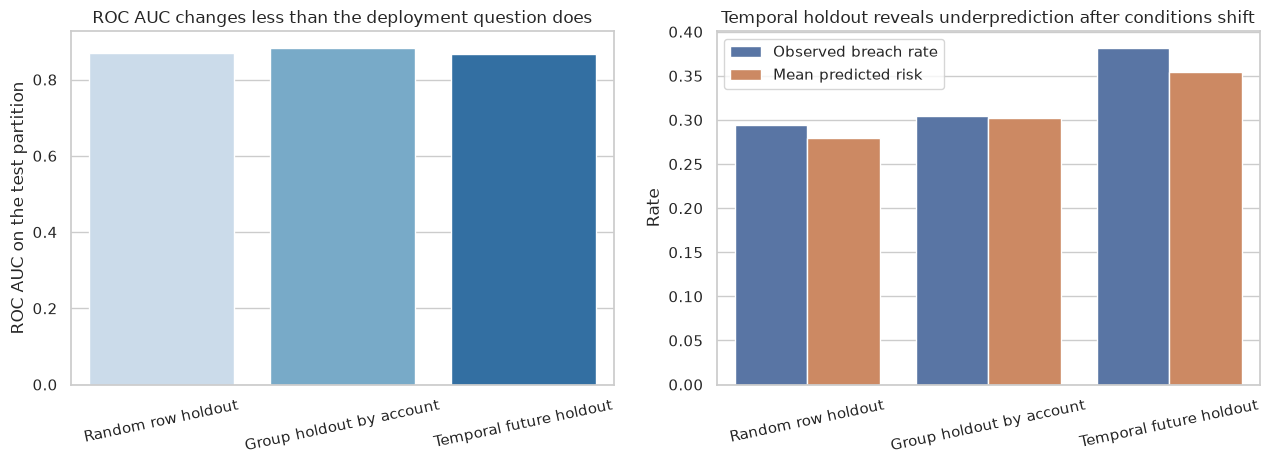

In [4]:
numeric_features = [
    "active_seats",
    "usage_ratio",
    "backlog_ratio",
    "critical_incidents_30d",
    "avg_response_hours_30d",
    "prior_escalation_rate",
]
categorical_features = ["region", "tier", "industry"]
proper_features = numeric_features + categorical_features


def make_baseline_pipeline():
    """Construct the baseline pipeline helper used in the 04. Train, Validation, Test Splits, and Leakage Control workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the baseline pipeline workflow.
    """
    return Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(numeric_features, categorical_features)),
            ("model", LogisticRegression(max_iter=4000)),
        ]
    )


split_artifacts = {}

# Random row split: 60 / 20 / 20.
random_train, random_remaining = train_test_split(
    df,
    test_size=0.40,
    random_state=14,
    stratify=df["breach_next_month"],
)
random_validation, random_test = train_test_split(
    random_remaining,
    test_size=0.50,
    random_state=14,
    stratify=random_remaining["breach_next_month"],
)
random_metrics, random_scores = evaluate_holdout(
    make_baseline_pipeline(),
    random_train,
    random_test,
    proper_features,
)
split_artifacts["Random row holdout"] = {
    "train": random_train,
    "validation": random_validation,
    "test": random_test,
    "scores": random_scores,
}

# Group split: hold out entire accounts.
unique_accounts = df["account_id"].drop_duplicates().sample(frac=1, random_state=14).reset_index(drop=True)
train_ids = set(unique_accounts.iloc[: int(0.60 * len(unique_accounts))])
validation_ids = set(unique_accounts.iloc[int(0.60 * len(unique_accounts)) : int(0.80 * len(unique_accounts))])
test_ids = set(unique_accounts.iloc[int(0.80 * len(unique_accounts)) :])

group_train = df[df["account_id"].isin(train_ids)].copy()
group_validation = df[df["account_id"].isin(validation_ids)].copy()
group_test = df[df["account_id"].isin(test_ids)].copy()
group_metrics, group_scores = evaluate_holdout(
    make_baseline_pipeline(),
    group_train,
    group_test,
    proper_features,
)
split_artifacts["Group holdout by account"] = {
    "train": group_train,
    "validation": group_validation,
    "test": group_test,
    "scores": group_scores,
}

# Temporal split: train on months 1-8, validate on 9-10, test on 11-12.
temporal_train = df[df["month_index"] <= 8].copy()
temporal_validation = df[df["month_index"].isin([9, 10])].copy()
temporal_test = df[df["month_index"] >= 11].copy()
temporal_metrics, temporal_scores = evaluate_holdout(
    make_baseline_pipeline(),
    temporal_train,
    temporal_test,
    proper_features,
)
split_artifacts["Temporal future holdout"] = {
    "train": temporal_train,
    "validation": temporal_validation,
    "test": temporal_test,
    "scores": temporal_scores,
}

split_results = pd.DataFrame(
    [
        {
            "split_strategy": "Random row holdout",
            "train_rows": len(random_train),
            "validation_rows": len(random_validation),
            "test_rows": len(random_test),
            **random_metrics,
        },
        {
            "split_strategy": "Group holdout by account",
            "train_rows": len(group_train),
            "validation_rows": len(group_validation),
            "test_rows": len(group_test),
            **group_metrics,
        },
        {
            "split_strategy": "Temporal future holdout",
            "train_rows": len(temporal_train),
            "validation_rows": len(temporal_validation),
            "test_rows": len(temporal_test),
            **temporal_metrics,
        },
    ]
)
split_results["calibration_gap"] = split_results["mean_predicted_risk"] - split_results["observed_breach_rate"]

smart_display(split_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

sns.barplot(data=split_results, x="split_strategy", y="roc_auc", palette="Blues", ax=axes[0])
axes[0].set_title("ROC AUC changes less than the deployment question does")
axes[0].set_xlabel("")
axes[0].set_ylabel("ROC AUC on the test partition")
axes[0].tick_params(axis="x", rotation=12)

risk_plot = split_results.melt(
    id_vars="split_strategy",
    value_vars=["observed_breach_rate", "mean_predicted_risk"],
    var_name="quantity",
    value_name="rate",
)
risk_plot["quantity"] = risk_plot["quantity"].map(
    {
        "observed_breach_rate": "Observed breach rate",
        "mean_predicted_risk": "Mean predicted risk",
    }
)

sns.barplot(data=risk_plot, x="split_strategy", y="rate", hue="quantity", ax=axes[1])
axes[1].set_title("Temporal holdout reveals underprediction after conditions shift")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rate")
axes[1].tick_params(axis="x", rotation=12)
axes[1].legend(title="")

plt.tight_layout()
plt.show()


Use the The Same Model Under Different Split Designs output to decide what the analysis should do next. The result matters when it changes model selection, diagnostic work, threshold setting, or guardrail design.


### Discussion of the Split Results

The key lesson is not that one split is universally "best." The lesson is that each split answers a different question.

In this run, the random and grouped holdouts look fairly similar on ROC AUC because both evaluate the model in roughly the same operating regime. The temporal holdout is more revealing operationally: later months have a higher breach rate, and the model's average predicted risk falls below the realized rate. In other words, the temporal split exposes a calibration problem that a row-random split hides.

Notice also why PR AUC must be read carefully. The future holdout has a higher event prevalence, which mechanically changes the baseline difficulty of the task. That does not make PR AUC useless, but it does mean that prevalence and calibration should travel with the metric table rather than sit off to the side.


## 4. Validation, Test, and the Temptation to Reuse the Test Set

A standard three-way workflow is:

1. Fit candidate models on the training set.
2. Use the validation set to choose hyperparameters or thresholds.
3. Evaluate the chosen workflow once on the test set.

In practice, teams often keep peeking at the test results while comparing candidates. Once that happens, the test set is no longer external. To make this visible, we will create a small **audit holdout** that stays untouched until the very end. The audit set is not required in every project, but it is useful pedagogically because it shows what test-set reuse can cost.


,max_depth,min_samples_leaf,validation_pr_auc,test_pr_auc,audit_pr_auc
7,5,30,0.688,0.797,0.810
9,8,5,0.687,0.799,0.809
11,8,30,0.687,0.800,0.808
5,5,5,0.685,0.796,0.809
15,None,30,0.684,0.799,0.810
10,8,15,0.683,0.797,0.809
6,5,15,0.683,0.797,0.809
4,5,1,0.682,0.799,0.810


,selection_rule,max_depth,min_samples_leaf,validation_pr_auc,test_pr_auc,audit_pr_auc
0,"Choose by validation, report on test",5,30,0.688000,0.797000,0.810000
1,"Choose by test, then report the same test",8,30,0.687000,0.800000,0.808000


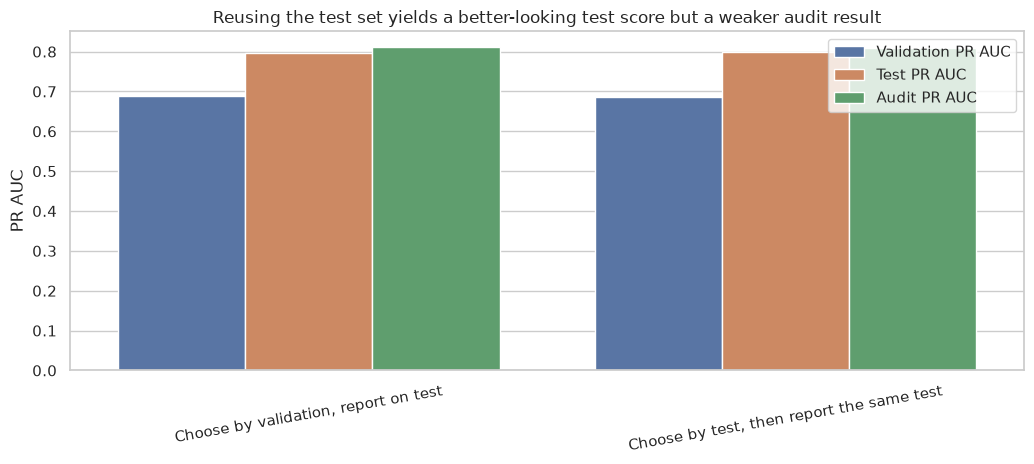

In [5]:
# Section focus: 4. Validation, Test, and the Temptation to Reuse the Test Set.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

tuning_train = df[df["month_index"] <= 7].copy()
tuning_validation = df[df["month_index"] == 8].copy()
tuning_test = df[df["month_index"] == 9].copy()
tuning_audit = df[df["month_index"] >= 10].copy()

candidate_rows = []
for max_depth in [3, 5, 8, None]:
    for min_leaf in [1, 5, 15, 30]:
        candidate_pipeline = Pipeline(
            steps=[
                ("preprocessor", build_preprocessor(numeric_features, categorical_features)),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=120,
                        max_depth=max_depth,
                        min_samples_leaf=min_leaf,
                        max_features="sqrt",
                        random_state=0,
                        n_jobs=-1,
                    ),
                ),
            ]
        )
        candidate_pipeline.fit(tuning_train[proper_features], tuning_train["breach_next_month"])

        validation_score = candidate_pipeline.predict_proba(tuning_validation[proper_features])[:, 1]
        test_score = candidate_pipeline.predict_proba(tuning_test[proper_features])[:, 1]
        audit_score = candidate_pipeline.predict_proba(tuning_audit[proper_features])[:, 1]

        candidate_rows.append(
            {
                "max_depth": "None" if max_depth is None else max_depth,
                "min_samples_leaf": min_leaf,
                "validation_pr_auc": average_precision_score(tuning_validation["breach_next_month"], validation_score),
                "test_pr_auc": average_precision_score(tuning_test["breach_next_month"], test_score),
                "audit_pr_auc": average_precision_score(tuning_audit["breach_next_month"], audit_score),
            }
        )

candidate_results = pd.DataFrame(candidate_rows)
validation_choice = candidate_results.sort_values("validation_pr_auc", ascending=False).iloc[0]
test_choice = candidate_results.sort_values("test_pr_auc", ascending=False).iloc[0]

selection_comparison = pd.DataFrame(
    [
        {
            "selection_rule": "Choose by validation, report on test",
            "max_depth": validation_choice["max_depth"],
            "min_samples_leaf": validation_choice["min_samples_leaf"],
            "validation_pr_auc": validation_choice["validation_pr_auc"],
            "test_pr_auc": validation_choice["test_pr_auc"],
            "audit_pr_auc": validation_choice["audit_pr_auc"],
        },
        {
            "selection_rule": "Choose by test, then report the same test",
            "max_depth": test_choice["max_depth"],
            "min_samples_leaf": test_choice["min_samples_leaf"],
            "validation_pr_auc": test_choice["validation_pr_auc"],
            "test_pr_auc": test_choice["test_pr_auc"],
            "audit_pr_auc": test_choice["audit_pr_auc"],
        },
    ]
)

smart_display(candidate_results.sort_values("validation_pr_auc", ascending=False).head(8).round(3))
smart_display(selection_comparison.round(3))

plot_selection = selection_comparison.melt(
    id_vars=["selection_rule", "max_depth", "min_samples_leaf"],
    value_vars=["validation_pr_auc", "test_pr_auc", "audit_pr_auc"],
    var_name="dataset",
    value_name="pr_auc",
)
plot_selection["dataset"] = plot_selection["dataset"].map(
    {
        "validation_pr_auc": "Validation PR AUC",
        "test_pr_auc": "Test PR AUC",
        "audit_pr_auc": "Audit PR AUC",
    }
)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
sns.barplot(data=plot_selection, x="selection_rule", y="pr_auc", hue="dataset", ax=ax)
ax.set_title("Reusing the test set yields a better-looking test score but a weaker audit result")
ax.set_xlabel("")
ax.set_ylabel("PR AUC")
ax.tick_params(axis="x", rotation=10)
ax.legend(title="")
plt.tight_layout()
plt.show()


In Validation, Test, and the Temptation to Reuse the Test Set, the point of the output is practical. The result should make the next modeling or review choice easier to state.


### Discussion of Test-Set Reuse

The difference is not huge, and that is exactly why the mistake survives in practice. When teams reuse the test set, the problem often looks harmless because the metric bump is small and plausible. But the logic has still broken: the reported test score is no longer an external performance estimate.

In this run, the model chosen by test PR AUC earns the best-looking test number, yet it does not carry the same advantage into the untouched audit period. That is the essential pattern to watch for. Once the test set becomes part of the search process, it stops behaving like a test set.


## 5. Leakage From Post-Outcome Fields

Now we hold the temporal split fixed and change the feature set. The proper feature set contains only variables that are available when the monthly decision should be made. The leaky feature set adds two fields that are logged after risk has already surfaced:

- `war_room_hours_next_14d`
- `rescue_override_next_14d`

These are reactive interventions, even though they can look like correlated predictors. If they enter the model, the workflow is no longer learning what can be known at decision time.


,feature_set,roc_auc,pr_auc,brier_score,observed_breach_rate,mean_predicted_risk
0,Proper decision-time features,0.867000,0.822000,0.141000,0.381000,0.354000
1,Leaky post-outcome features included,1.000000,1.000000,0.001000,0.381000,0.384000


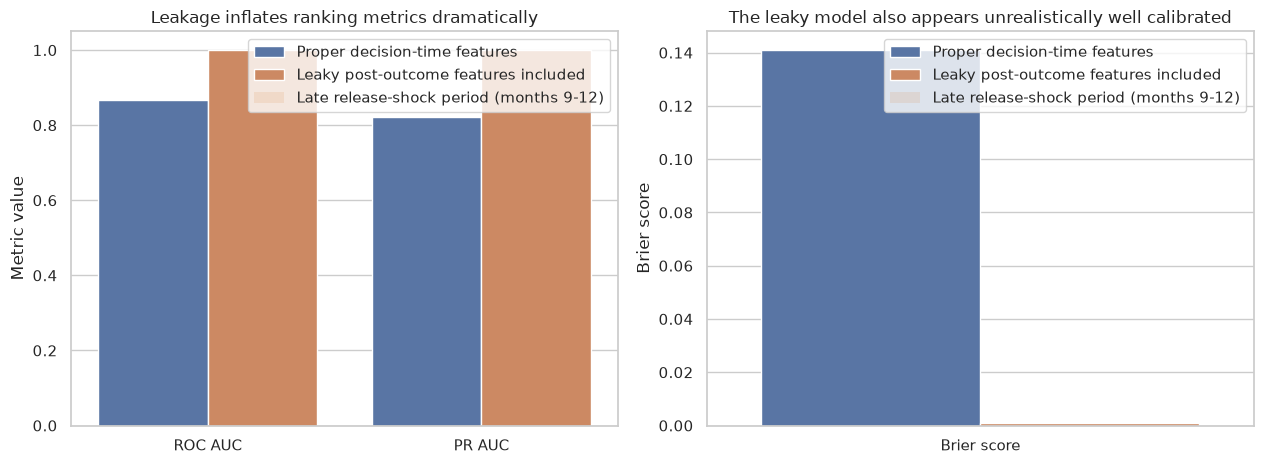

In [6]:
# Section focus: 5. Leakage From Post-Outcome Fields.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

leaky_numeric_features = numeric_features + ["war_room_hours_next_14d", "rescue_override_next_14d"]
leaky_features = proper_features + ["war_room_hours_next_14d", "rescue_override_next_14d"]

proper_temporal_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_features, categorical_features)),
        ("model", LogisticRegression(max_iter=4000)),
    ]
)
leaky_temporal_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(leaky_numeric_features, categorical_features)),
        ("model", LogisticRegression(max_iter=4000)),
    ]
)

proper_temporal_metrics, proper_temporal_scores = evaluate_holdout(
    proper_temporal_pipeline,
    temporal_train,
    temporal_test,
    proper_features,
)
leaky_temporal_metrics, leaky_temporal_scores = evaluate_holdout(
    leaky_temporal_pipeline,
    temporal_train,
    temporal_test,
    leaky_features,
)

leakage_comparison = pd.DataFrame(
    [
        {"feature_set": "Proper decision-time features", **proper_temporal_metrics},
        {"feature_set": "Leaky post-outcome features included", **leaky_temporal_metrics},
    ]
)

smart_display(leakage_comparison.round(3))

plot_metrics = leakage_comparison.melt(
    id_vars="feature_set",
    value_vars=["roc_auc", "pr_auc", "brier_score"],
    var_name="metric",
    value_name="value",
)
plot_metrics["metric"] = plot_metrics["metric"].map(
    {"roc_auc": "ROC AUC", "pr_auc": "PR AUC", "brier_score": "Brier score"}
)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

sns.barplot(
    data=plot_metrics[plot_metrics["metric"].isin(["ROC AUC", "PR AUC"])],
    x="metric",
    y="value",
    hue="feature_set",
    ax=axes[0],
)
axes[0].set_title("Leakage inflates ranking metrics dramatically")
axes[0].set_xlabel("")
axes[0].set_ylabel("Metric value")
handles_0, labels_0 = axes[0].get_legend_handles_labels()
axes[0].legend(handles_0 + [late_regime_patch], labels_0 + [late_regime_patch.get_label()], title="")

sns.barplot(
    data=plot_metrics[plot_metrics["metric"] == "Brier score"],
    x="metric",
    y="value",
    hue="feature_set",
    ax=axes[1],
)
axes[1].set_title("The leaky model also appears unrealistically well calibrated")
axes[1].set_xlabel("")
axes[1].set_ylabel("Brier score")
handles_1, labels_1 = axes[1].get_legend_handles_labels()
axes[1].legend(handles_1 + [late_regime_patch], labels_1 + [late_regime_patch.get_label()], title="")

plt.tight_layout()
plt.show()


These numbers translate model behavior into decision consequences. For Leakage From Post-Outcome Fields, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


### Discussion of the Leakage Results

This is the cleanest failure mode in the notebook. Once reactive future fields enter the design, the model looks almost too good to question. That is not evidence of brilliance. It is evidence that the workflow has learned from information that should never have been available at prediction time.

Kaufman et al. (2012) use the term *leakage* for exactly this situation: the target or its downstream consequences become available to the learner through channels that will not exist in honest deployment. Operationally, such models are dangerous because the optimism appears highly quantitative and therefore highly convincing.


## 6. Rolling Validation Through Time

A single future holdout tells us something important, but it can still hide instability. Rolling validation asks a stronger question: if we repeatedly refit the model using the past and validate on the next month, do the errors stay stable?

This matters in decision systems because thresholds, staffing plans, and service-level commitments are often maintained month after month throughout the model lifecycle.


,validation_month,n_train_months,observed_breach_rate,mean_predicted_risk,roc_auc,pr_auc,brier_score
0,6,5,0.253,0.292,0.861,0.722,0.125
1,7,6,0.221,0.278,0.862,0.713,0.115
2,8,7,0.220,0.274,0.871,0.685,0.113
3,9,8,0.364,0.351,0.856,0.803,0.145
4,10,9,0.363,0.356,0.867,0.812,0.137
5,11,10,0.377,0.353,0.878,0.843,0.133
6,12,11,0.386,0.360,0.857,0.804,0.148


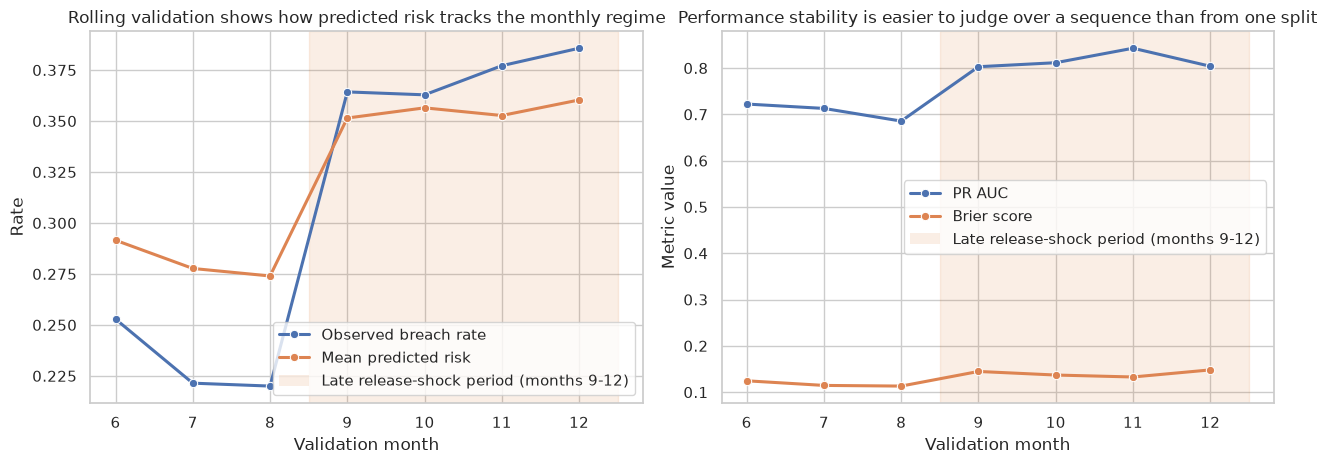

In [7]:
# Section focus: 6. Rolling Validation Through Time.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

rolling_rows = []
for validation_month in range(6, 13):
    rolling_train = df[df["month_index"] < validation_month].copy()
    rolling_validation = df[df["month_index"] == validation_month].copy()

    rolling_pipeline = make_baseline_pipeline()
    rolling_pipeline.fit(rolling_train[proper_features], rolling_train["breach_next_month"])
    rolling_score = rolling_pipeline.predict_proba(rolling_validation[proper_features])[:, 1]

    rolling_rows.append(
        {
            "validation_month": validation_month,
            "n_train_months": validation_month - 1,
            "observed_breach_rate": rolling_validation["breach_next_month"].mean(),
            "mean_predicted_risk": rolling_score.mean(),
            "roc_auc": roc_auc_score(rolling_validation["breach_next_month"], rolling_score),
            "pr_auc": average_precision_score(rolling_validation["breach_next_month"], rolling_score),
            "brier_score": brier_score_loss(rolling_validation["breach_next_month"], rolling_score),
        }
    )

rolling_results = pd.DataFrame(rolling_rows)
smart_display(rolling_results.round(3))

rolling_rates = rolling_results.melt(
    id_vars=["validation_month", "n_train_months"],
    value_vars=["observed_breach_rate", "mean_predicted_risk"],
    var_name="quantity",
    value_name="rate",
)
rolling_rates["quantity"] = rolling_rates["quantity"].map(
    {
        "observed_breach_rate": "Observed breach rate",
        "mean_predicted_risk": "Mean predicted risk",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

sns.lineplot(data=rolling_rates, x="validation_month", y="rate", hue="quantity", marker="o", linewidth=2.2, ax=axes[0])
axes[0].axvspan(8.5, 12.5, color="#D55E00", alpha=0.10)
axes[0].set_title("Rolling validation shows how predicted risk tracks the monthly regime")
axes[0].set_xlabel("Validation month")
axes[0].set_ylabel("Rate")
handles_0, labels_0 = axes[0].get_legend_handles_labels()
axes[0].legend(handles_0 + [late_regime_patch], labels_0 + [late_regime_patch.get_label()], title="")

rolling_metrics = rolling_results.melt(
    id_vars=["validation_month", "n_train_months"],
    value_vars=["pr_auc", "brier_score"],
    var_name="metric",
    value_name="value",
)
rolling_metrics["metric"] = rolling_metrics["metric"].map(
    {"pr_auc": "PR AUC", "brier_score": "Brier score"}
)

sns.lineplot(data=rolling_metrics, x="validation_month", y="value", hue="metric", marker="o", linewidth=2.2, ax=axes[1])
axes[1].axvspan(8.5, 12.5, color="#D55E00", alpha=0.10)
axes[1].set_title("Performance stability is easier to judge over a sequence than from one split")
axes[1].set_xlabel("Validation month")
axes[1].set_ylabel("Metric value")
handles_1, labels_1 = axes[1].get_legend_handles_labels()
axes[1].legend(handles_1 + [late_regime_patch], labels_1 + [late_regime_patch.get_label()], title="")

plt.tight_layout()
plt.show()


Rolling Validation Through Time gives a checkpoint for the decision workflow. Use the output to choose the next model check, threshold review, or guardrail.


### Discussion of Rolling Validation

The rolling results make the regime change much more visible than a single test split does. Around month 9, observed breach rates rise and the error profile changes with them. A random holdout would average across these conditions and produce a cleaner-looking number, but that cleaner number would say less about whether the model is ready for ongoing operations.

This is one of the main reasons to prefer rolling or blocked temporal validation in decision systems that will be run repeatedly over time. The objective is not to maximize elegance; it is to see the instability before deployment sees it for you.


## 7. Practical Evaluation Checklist

| Question | Why it matters |
|---|---|
| What future is the test set supposed to represent? | A split is meaningful only relative to a deployment question |
| Are repeated entities crossing train and test? | Group dependence can make row-level holdouts too optimistic |
| Does time order matter? | Forecasting and operational monitoring require forward-looking validation |
| Which decisions are made on the validation set? | Hyperparameter and threshold choices belong there, not on the test set |
| Has the test set been consulted repeatedly? | Repeated use turns a test set into another tuning surface |
| Are any features recorded after the decision point? | Post-outcome or post-intervention fields create leakage |
| Do metrics travel with prevalence and calibration checks? | Discrimination alone can hide regime changes and threshold risk |
| Would rolling validation reveal a different story? | Stability over time often matters more than one lucky holdout |

This checklist is not administrative ceremony. It is part of the model itself, because the reported model quality depends on it.


## Wrap-Up

The central lesson of this notebook is that evaluation design is a modeling choice. Train, validation, and test sets are not generic containers that can be swapped in any convenient way. They encode a claim about the future, and the quality of that claim determines how trustworthy the final metric will be.

A professional workflow therefore does three things carefully:

1. matches the split strategy to the deployment question,
2. keeps validation and test roles separate,
3. and blocks leakage from both time order and downstream interventions.

When those disciplines are ignored, even sophisticated models become hard to trust. When they are respected, even simple models can support defensible operational decisions.

## References

- Ambroise, C., & McLachlan, G. J. (2002). *Selection bias in gene extraction on the basis of microarray gene-expression data.* *Proceedings of the National Academy of Sciences, 99*(10), 6562-6566. [https://doi.org/10.1073/pnas.102102699](https://doi.org/10.1073/pnas.102102699)
- Breiman, L. (2001). *Statistical Modeling: The Two Cultures (with comments and a rejoinder by the author).* *Statistical Science, 16*(3). [https://doi.org/10.1214/ss/1009213726](https://doi.org/10.1214/ss/1009213726)
- Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). *Leakage in data mining.* *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21. [https://doi.org/10.1145/2382577.2382579](https://doi.org/10.1145/2382577.2382579)
- Roberts, D. R., Bahn, V., Ciuti, S., et al. (2017). *Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure.* *Ecography, 40*(8), 913-929. [https://doi.org/10.1111/ecog.02881](https://doi.org/10.1111/ecog.02881)
- Wieczorek, J., Guerin, C., & McMahon, T. E. (2022). *K-fold cross-validation for complex sample surveys.* *Stat, 11*(1). [https://doi.org/10.1002/sta4.454](https://doi.org/10.1002/sta4.454)
